In [2]:
#File: homework9.ipynp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

In [45]:
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")
df.shape # the data has 100 rows and 6 columns
print(df.head())
print(df.tail())
print(df.columns)

          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


In [19]:
def model(x, A, k):
    return A * np.exp(-k*x)

x = df['x']
y_noise_1 = df['y_noise_1']

p0 = [1,1]
popt, pcov = opt.curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt

print(f'Fit: {A_fit:.2f} * e^({-k_fit:.2f} * x)')

Fit: 4.71 * e^(-0.92 * x)


In [21]:
residuals = y_noise_1 - model(x, A_fit,k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_red = chi2/dof

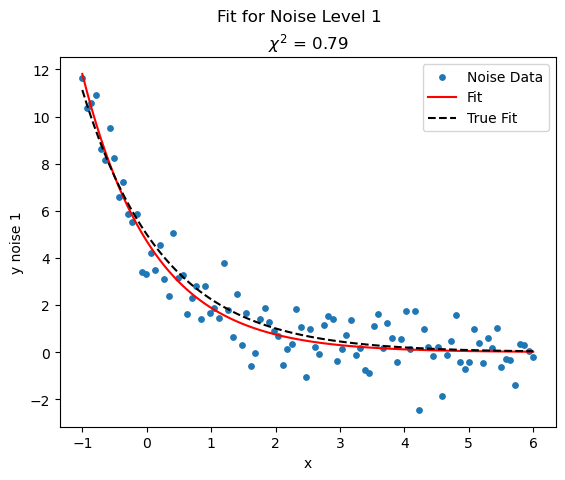

In [28]:
plt.figure()

plt.scatter(x, y_noise_1, label = "Noise Data", s = 15)
plt.plot(x, model(x,A_fit,k_fit), label = "Fit", c = "red")
plt.plot(x, model(x, 5, 0.8), linestyle = "--", label = "True Fit", c= 'black')

plt.suptitle("Fit for Noise Level 1")
plt.title(f'$\chi^2$ = {chi2_red:.2f}')
plt.xlabel("x")
plt.ylabel("y noise 1")
plt.legend()

plt.show()            

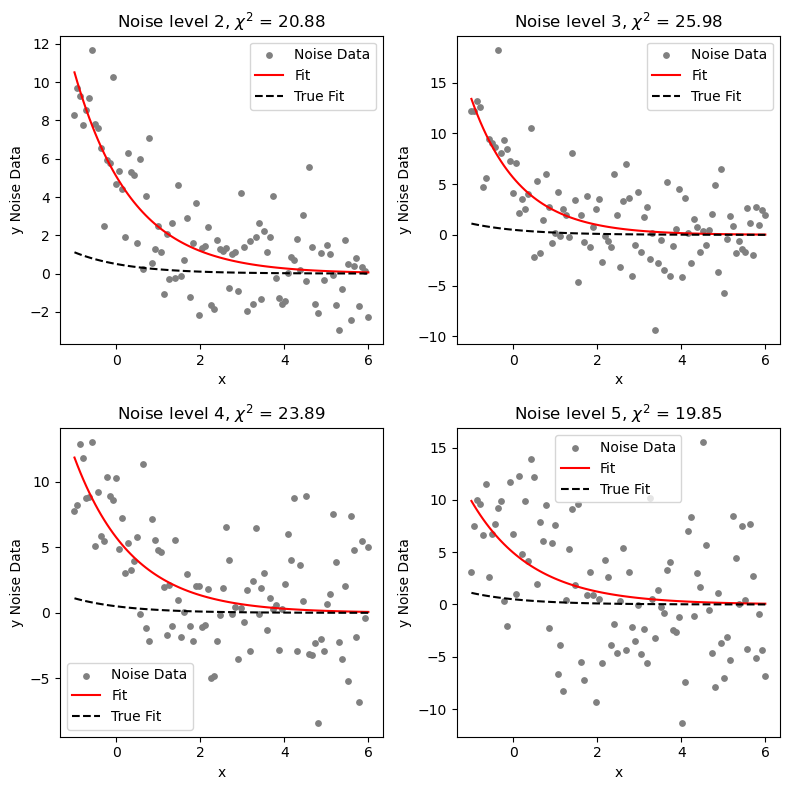

In [146]:
def fit_model(x, y):
    p0 = [1,1]
    popt, pcov = opt.curve_fit(model, x, y, p0 = p0)
    param_1, param_2 = popt
    residuals = x - model(x, param_1, param_2)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_red = chi2 / dof
    return np.array([param_1, param_2, chi2_red])

fig, axs = plt.subplots(2,2, figsize = (8,8))

df_2 = pd.DataFrame()
df_2['Noise'] = []
df_2['A fit'] = []
df_2['k fit'] = []
df_2['chi squared'] = []
df_2.loc[0] = [1, A_fit, k_fit, chi2_red]

for i, row in enumerate(df.iloc[:,2:]):
    y = df[row]
    x = df['x']
    params = fit_model(x, y)
    df_2.loc[i+1] = [i+2, params[0], params[1], params[2]]
    axs_flat = axs.flatten()
    axs_flat[i].scatter(x, y, c = 'gray', s = 15, label = 'Noise Data')
    axs_flat[i].plot(x, model(x, params[0], params[1]), c = 'r', label = 'Fit')
    axs_flat[i].plot(x, model(x, 0.5, 0.8), c = 'black', label = 'True Fit', linestyle = "--")
    axs_flat[i].legend()
    axs_flat[i].set_title(f'Noise level {i+2}, $\chi^2$ = {params[2]:.2f}')
    axs_flat[i].set_xlabel('x')
    axs_flat[i].set_ylabel('y Noise Data')
    
fig.tight_layout()        
plt.show()

# As the noise level increases the chi squared kind of increases but noise level 3 has the highest chi squared
# As the noise level increases the red and black lines get further apart because the data is skewing the fit

In [147]:
print(df_2) # defined the dataframe in the previous cell since each parameter was defined in the for loop

df_2.to_csv("noisy_parameters.csv", index = False)

   Noise     A fit     k fit  chi squared
0    1.0  4.714814  0.918308     0.790673
1    2.0  5.063889  0.730396    20.875085
2    3.0  5.609396  0.870372    25.983667
3    4.0  5.738727  0.725965    23.894638
4    5.0  4.943458  0.695012    19.852507
